# pymoo GA: Fit non ideal diode equation to dark JV-curves

This notebook was written to fit dark JV-curves with the non-ideal diode equation below:  
For dark:

$$ J = J_0\left[\exp\left(-\frac{V-R_s J}{n k_b T}\right)-1\right] + \frac{V-R_s J}{R_{sh}}$$

using the solving method decribed in [Solid-State Electronics 44 (2000) 1861-1864](https://doi.org/10.1016/S0038-1101(00)00132-5)


In [1]:
# Import necessary libraries
import warnings, os, sys, copy
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer
    from optimpv.models.Diodefits.DiodeAgent import DiodeAgent
    from optimpv.models.Diodefits.DiodeModel import *
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer
    from optimpv.models.Diodefits.DiodeAgent import DiodeAgent
    from optimpv.models.Diodefits.DiodeModel import *

## Define the parameters for the simulation

In [2]:
params = []

J0 = FitParam(name = 'J0', value = 1e-5, bounds = [1e-6,1e-3], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$J_0$', unit='A m$^{-2}$', axis_type = 'log',force_log=True)
params.append(J0)

n = FitParam(name = 'n', value = 1.5, bounds = [1,2], log_scale = False, value_type = 'float', type='range', display_name=r'$n$', unit='', axis_type = 'linear')
params.append(n)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-5,1e-3], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$R_{\text{series}}$', unit=r'$\Omega$ m$^2$', axis_type = 'log',force_log=True)
params.append(R_series)

R_shunt = FitParam(name = 'R_shunt', value = 1e-1, bounds = [1e-2,1e2], log_scale = True, rescale = False, value_type = 'float', type='range', display_name=r'$R_{\text{shunt}}$', unit=r'$\Omega$ m$^2$', axis_type = 'log',force_log=True)
params.append(R_shunt)

# original values
params_orig = copy.deepcopy(params)
num_free_params = len([p for p in params if p.type != 'fixed'])

## Generate some fake data for the dark JV

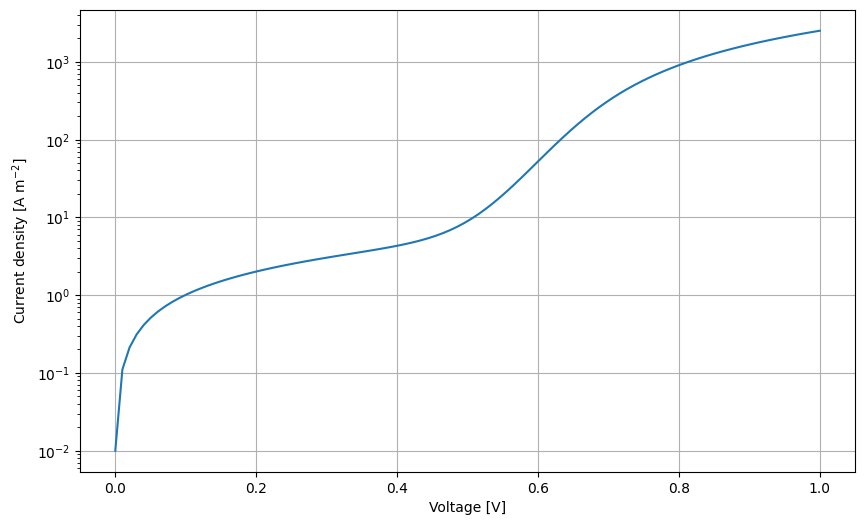

In [3]:
# Create JV to fit
X = np.linspace(0.001,1,100)
y = NonIdealDiode_dark(X, J0.value, n.value, R_series.value, R_shunt.value)

plt.figure(figsize=(10,6))
plt.semilogy(X,y)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.grid()
plt.show()


## Run the optimization
While very inefficient we first try to fit the data using Bayesian optimization, then we use `scipy.optimize.minize` to demonstrate the difference in speed and accuracy.

In [4]:
# Define the Agent and the target metric/loss function
metric = 'mse' # can be 'nrmse', 'mse', 'mae'
loss = 'soft_l1' # can be 'linear', 'huber', 'soft_l1'
exp_format = 'dark' # can be 'dark', 'light' depending on the type of data you have
use_pvlib = False # if True, use pvlib to calculate the diode model if not use the implementation in DiodeModel.py

diode = DiodeAgent(params, X, y, metric = metric, loss = loss, minimize=True,exp_format=exp_format,use_pvlib=use_pvlib,transforms='log')

In [5]:
# Create PymooOptimizer for single-objective optimization
optimizer = PymooOptimizer(params=params, agents=[diode], algorithm='GA', pop_size=20, n_gen=100, name='pymoo_single_obj', verbose_logging=False)

In [6]:
res = optimizer.optimize()

In [7]:
# Update parameters with best results
optimizer.update_params_with_best_balance()
diode.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p,po in zip(optimizer.params, params_orig):
    print(p.name, 'fitted value:', p.value, 'original value:', po.value)

Best parameters:
J0 fitted value: 3.0436279849376313e-05 original value: 1e-05
n fitted value: 1.6223456260559468 original value: 1.5
R_series fitted value: 8.928938813539872e-05 original value: 0.0001
R_shunt fitted value: 0.10184554168852354 original value: 0.1


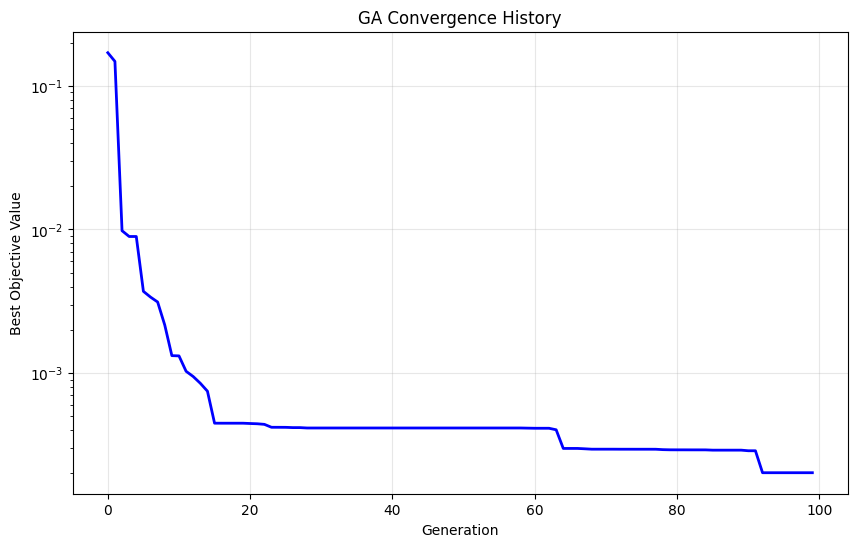

In [8]:
optimizer.plot_convergence(yscale='log', xscale='linear')

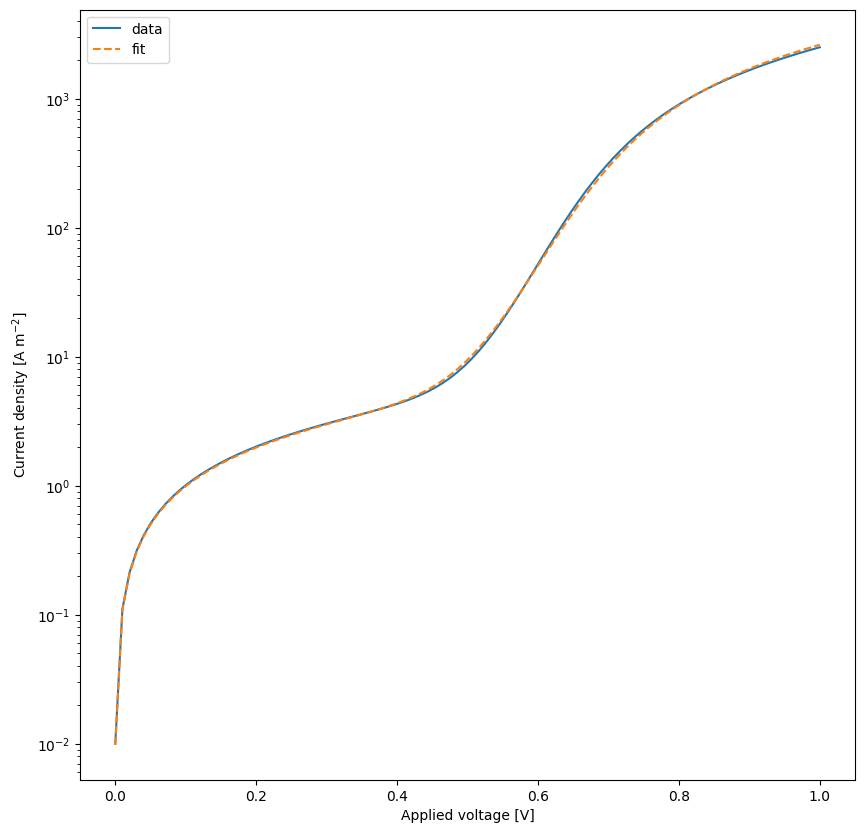

In [9]:
# rerun the simulation with the best parameters
yfit = diode.run(parameters={})

plt.figure(figsize=(10,10))
plt.plot(X,y,label='data')
plt.plot(X,yfit,label='fit',linestyle='--')
plt.xscale('linear')
plt.yscale('log')
plt.xlabel('Applied voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()